# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Models

### Planck

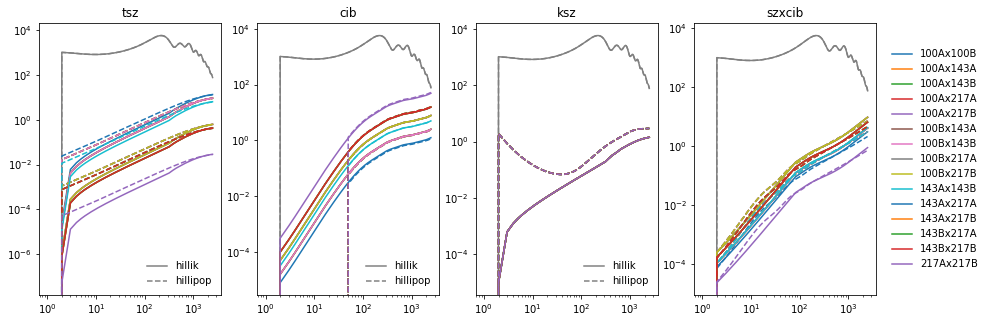

In [31]:
import itertools
xfreq = list(itertools.combinations( ['100A','100B','143A','143B','217A','217B'],2))

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_plk_fgs.npy")))
fg_list = ["dust","tsz","ksz","cib","szxcib","ps_radio","ps_dusty","ps"]
hlp = dict( zip(fg_list,np.load( f"{DBdir}/../hillipop_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','hillipop'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label="%sx%s" % xfreq[c])
        p2=plot( abs(hlp[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### SPT

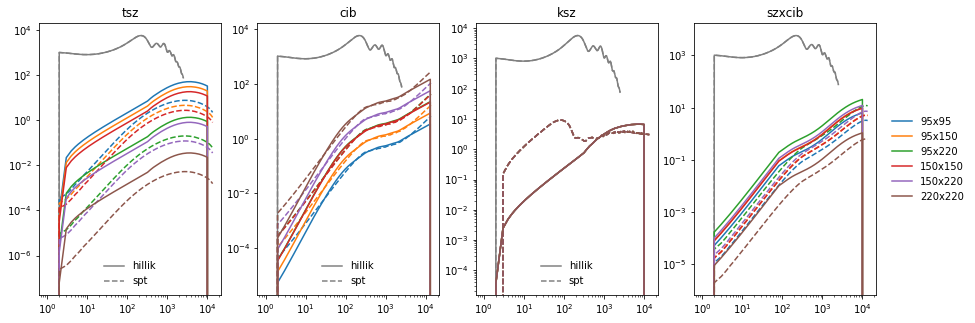

In [30]:
xfreq = ["95x95","95x150","95x220","150x150","150x220","220x220"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_spt_fgs.npy")))
fg_list = ["ps_dg","cib","ps_rg","tsz","ksz","dust","szxcib","szxradio"]
spt = dict( zip(fg_list,np.load( f"{DBdir}/../spt_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','spt'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(spt[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (deep)

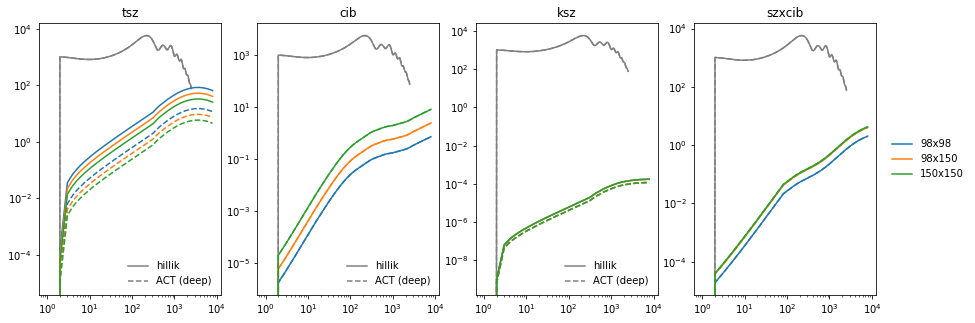

In [28]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTd_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_deep_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (deep)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (wide)

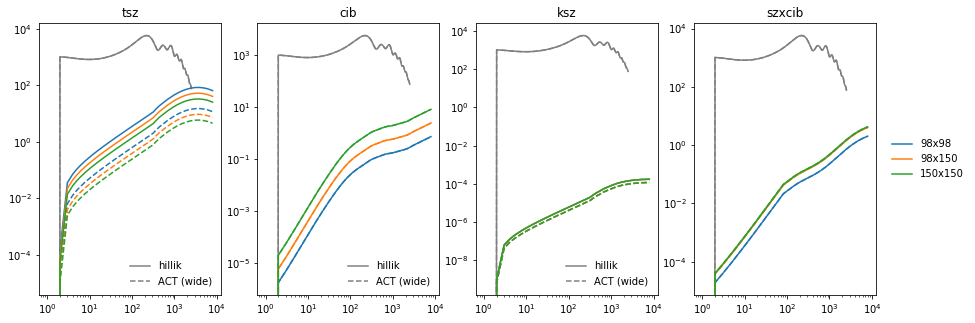

In [29]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTw_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_wide_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (wide)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

## Each survey

In [6]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.7) for run in runnames]

hillik_plk: 131417  160184  314075  206727 
hillik_spt: 448083  370380  347201  419869 
hillik_act: 318241  200576  233963  197728 


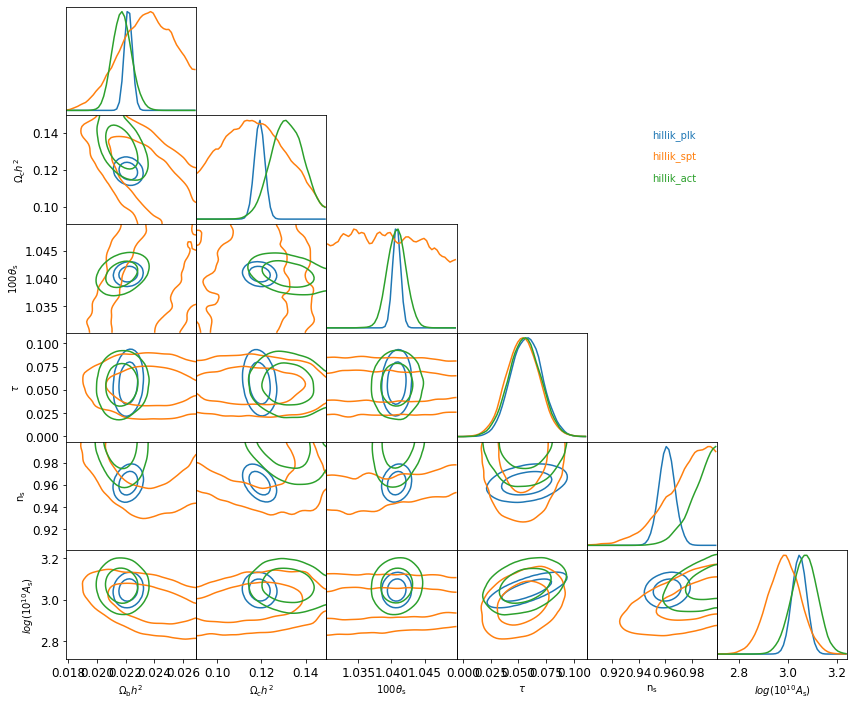

In [7]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

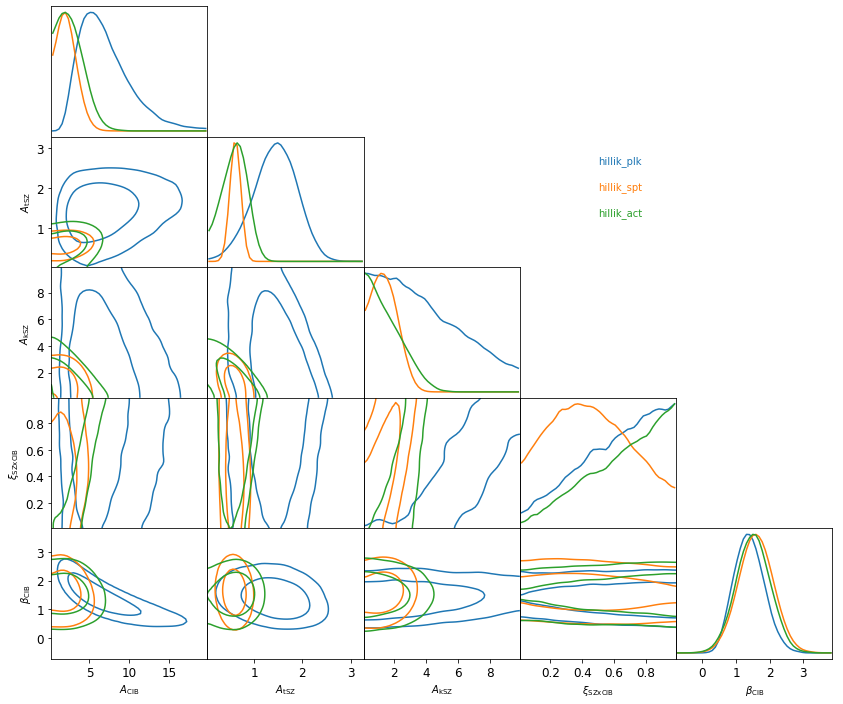

In [18]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Combination

In [32]:
runnames = ['hillik_plk','hillik_plk_spt','hillik_plk_act','hillik_plk_spt_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk: 34598  35882  39734  28936 
hillik_plk_spt: 708321  436249  376755  601921 
hillik_plk_act: 540376  716883  446944  446720 
hillik_plk_spt_act: 340016  494686  324149  655288 


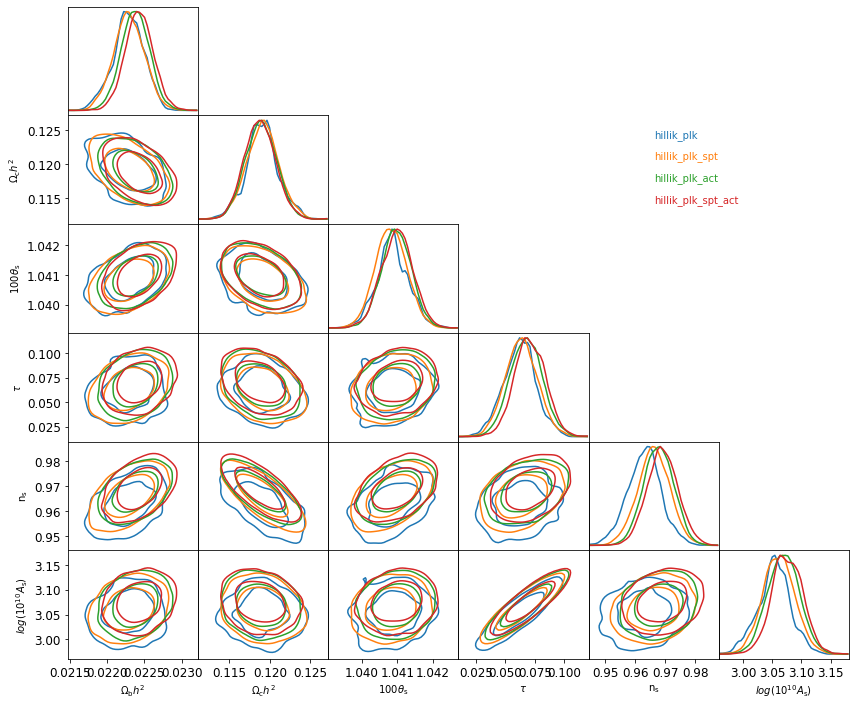

In [33]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

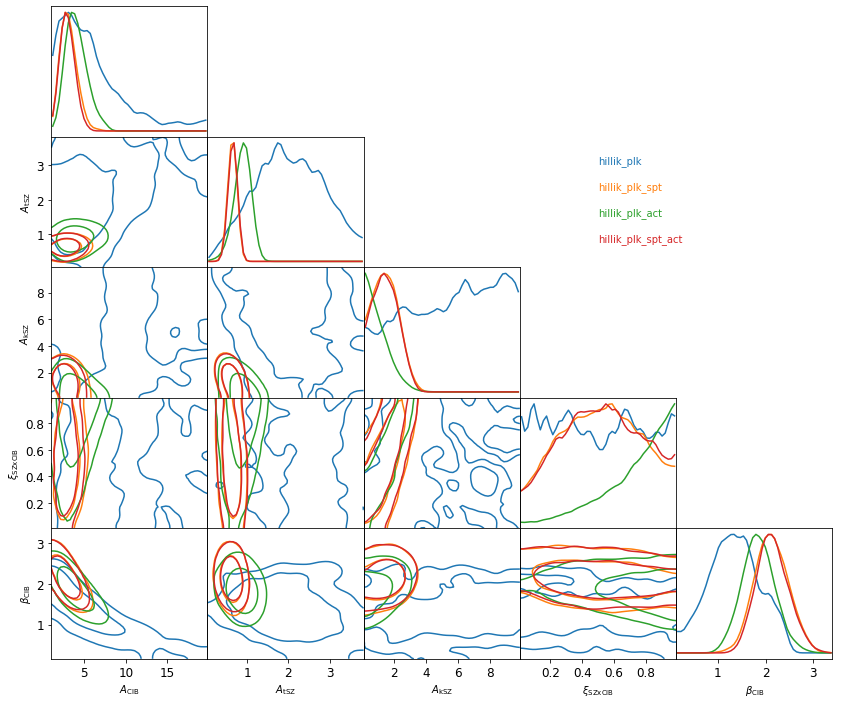

In [34]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Alens
<span style="color:red">**Not converged yet !**</span>

In [9]:
runnames = ['hillik_plk_Alens','hillik_act_Alens','hillik_spt_Alens','hillik_plk_spt_act_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8) for run in runnames]

hillik_plk_Alens: 66361  67375  47570  52024 
hillik_act_Alens: 170217  160093  146987  146397 
hillik_spt_Alens: 179155  181773  208760  156288 
hillik_plk_spt_act_Alens: 31051  41198  35504  34055 


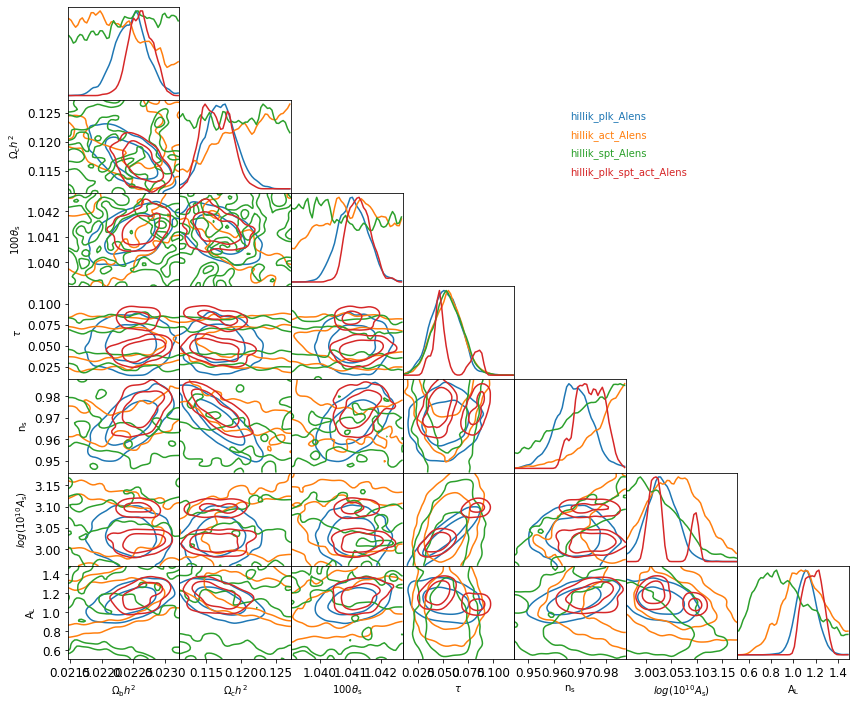

In [10]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.triangle( chains, listpar, labels=runnames)